                                Spam Me Detection using Naive Bayes and CountVectorizer

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Dataset
df = pd.read_csv('spam.csv', encoding='latin-1')
df = df[['v1', 'v2']]

In [3]:
print("Original Columns: ")
print(df.columns)

print("\nFirst 5 rows of dataset: ")
print(df.head())

Original Columns: 
Index(['v1', 'v2'], dtype='str')

First 5 rows of dataset: 
     v1                                                 v2
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [4]:
# Rename Columns for better readability 

df = df.rename(columns={'v1':'label', 'v2':'message'})

print("\nAfter Renaming Columns: ")
print(df.head())


After Renaming Columns: 
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [5]:
# Explore Dataset (EDA)

print("\nShape of dataset: ")
print(df.shape)

print("\nSpam vs Ham Count: ")
print(df['label'].value_counts())

print("\nNull Values: ")
print(df.isnull().sum())


Shape of dataset: 
(5572, 2)

Spam vs Ham Count: 
label
ham     4825
spam     747
Name: count, dtype: int64

Null Values: 
label      0
message    0
dtype: int64


In [6]:
# Data Preprocessing
df['label_num'] = df['label'].map({'ham':0,'spam':1})

As we can see there is no null value we can directly head to our next step without worrying about handling null values

In [7]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    df['message'], df['label_num'],
    test_size=0.2, random_state=42
)

print("\nTraining size: ", X_train.shape)
print("\nTesting Size: ", X_test.shape)


Training size:  (4457,)

Testing Size:  (1115,)


In [8]:
# Feature Extraction
vectorizer = CountVectorizer(
    stop_words='english',
    max_features=3000
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.fit_transform(X_test)

print(f"\nVocabulary Size: {len(vectorizer.vocabulary_)}")


Vocabulary Size: 3000


In [9]:
# Train Model
model = MultinomialNB()
model.fit(X_train_vec, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [10]:
# Predictions
y_pred = model.predict(X_test_vec)

In [11]:
# Evaluation

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy * 100:.2f}%")

print("\nClassification Report: ")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))


Accuracy: 78.83%

Classification Report: 
              precision    recall  f1-score   support

         Ham       0.95      0.80      0.87       965
        Spam       0.36      0.71      0.48       150

    accuracy                           0.79      1115
   macro avg       0.65      0.76      0.67      1115
weighted avg       0.87      0.79      0.81      1115



Confusion Matrix: 
[[772 193]
 [ 43 107]]


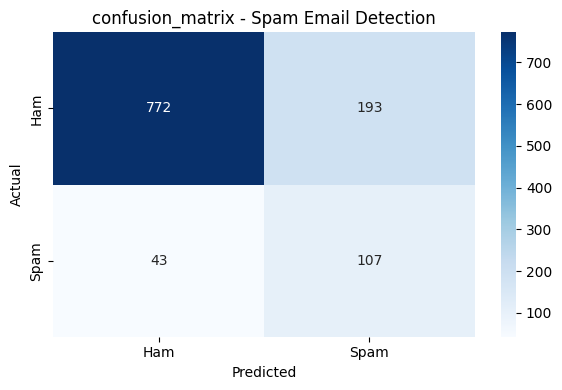

In [12]:
# Confusion Matrix(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix: ")
print(cm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title('confusion_matrix - Spam Email Detection')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

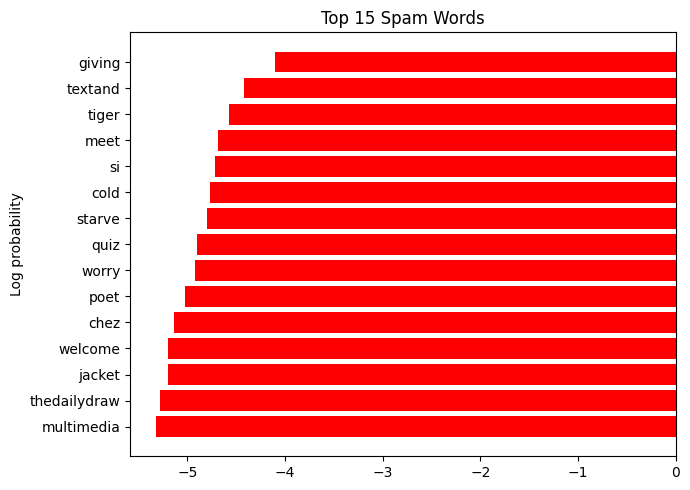

In [13]:
# Top Spam Words Chart
feature_names = vectorizer.get_feature_names_out()
log_prob_spam = model.feature_log_prob_[1]

top_indices = log_prob_spam.argsort()[-15:]
top_words = [feature_names[i] for i in top_indices]
top_scores = [log_prob_spam[i] for i in top_indices]

plt.figure(figsize=(7,5))
plt.barh(top_words, top_scores, color='red')
plt.title('Top 15 Spam Words')
plt.ylabel('Log probability')
plt.tight_layout()
plt.savefig('top_spam_words.png')
plt.show()